In [1]:
library(tidyverse)
library(bfast)

# Cargar datos
df <- read.csv("/home/rstudio/work/proyecto-cgsm/outputs/tables/serie_temporal_ndvi_definitiva.csv")
cat("Registros cargados:", nrow(df), "\n")
cat("Columnas:", names(df), "\n")
head(df)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: strucchangeRcpp

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich


Attaching package: ‘strucchangeRcpp’


The following object is masked from ‘package:stringr’:

    boundary




Registros cargados: 584 
Columnas: subzona date ndvi 


,subzona,date,ndvi
,<chr>,<chr>,<dbl>
1,Isla_Boqueron,2018-12-01,0.1630299
2,Isla_Boqueron,2019-01-01,0.2114152
3,Isla_Boqueron,2019-02-01,0.1421609
4,Isla_Boqueron,2019-03-01,0.1129351
5,Isla_Boqueron,2019-04-01,0.1338908
6,Isla_Boqueron,2019-06-01,0.1181851


In [5]:
estaciones <- unique(df$subzona)
resultados_bfast <- list()

for (est in estaciones) {
  cat("=== Procesando:", est, "===\n")
  sub <- df %>% filter(subzona == est) %>% arrange(date) %>% filter(!is.na(ndvi))
  
  if (nrow(sub) < 24) { 
    cat("  Insuficientes datos (", nrow(sub), "meses)\n\n")
    next 
  }
  
  ts_ndvi <- ts(sub$ndvi, 
                start = c(as.integer(format(as.Date(sub$date[1]), "%Y")),
                          as.integer(format(as.Date(sub$date[1]), "%m"))),
                frequency = 12)
  
  tryCatch({
    bf <- bfast(ts_ndvi, h = 0.15, season = "harmonic", max.iter = 10)
    
    # Contar quiebres de forma segura
    n_bt <- ifelse(bf$nobp$Vt, 0, length(bf$Vt.bp))
    n_bs <- ifelse(bf$nobp$Wt, 0, length(bf$Wt.bp))
    
    cat("  Quiebres tendencia:", n_bt, "| estacionalidad:", n_bs, "\n")
    
    resultados_bfast[[est]] <- data.frame(
      estacion = est, 
      quiebres_tendencia = n_bt, 
      quiebres_estacionalidad = n_bs
    )
    
    png(paste0("/home/rstudio/work/proyecto-cgsm/outputs/figures/bfast_", 
               gsub(" ","_",est), ".png"), width=1200, height=800, res=150)
    plot(bf, main=paste("BFAST -", est))
    dev.off()
    cat("  Grafico guardado\n\n")
    
  }, error = function(e) cat("  Error:", e$message, "\n\n"))
}

if (length(resultados_bfast) > 0) {
  resumen <- do.call(rbind, resultados_bfast)
  write.csv(resumen, "/home/rstudio/work/proyecto-cgsm/outputs/tables/bfast_resumen.csv", 
            row.names = FALSE)
  cat("\n=== RESUMEN BFAST ===\n")
  print(resumen)
}

cat("\n*** FASE 2 R COMPLETA ***\n")

=== Procesando: Isla_Boqueron ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: Punta_Cerro ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: Punta_Chino ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: Rio_Sevilla ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: Cano_Palos ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: CP_Luna ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: CP_Aguas_Negras ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado

=== Procesando: Cano_Clarin ===
  Quiebres tendencia: 0 | estacionalidad: 0 
  Grafico guardado


=== RESUMEN BFAST ===
                       estacion quiebres_tendencia quiebres_estacionalidad
Isla_Boqueron     Isla_Boqueron                  0                       0
Punta_Cerro         Punta_Cerro                  0

In [6]:
# Ver gráficos generados
list.files("/home/rstudio/work/proyecto-cgsm/outputs/figures/", pattern="bfast")

[1] "bfast_Cano_Clarin.png"     "bfast_Cano_Palos.png"     
[3] "bfast_CP_Aguas_Negras.png" "bfast_CP_Luna.png"        
[5] "bfast_Isla_Boqueron.png"   "bfast_Punta_Cerro.png"    
[7] "bfast_Punta_Chino.png"     "bfast_Rio_Sevilla.png"

NULL

Quiebres tendencia: 0 


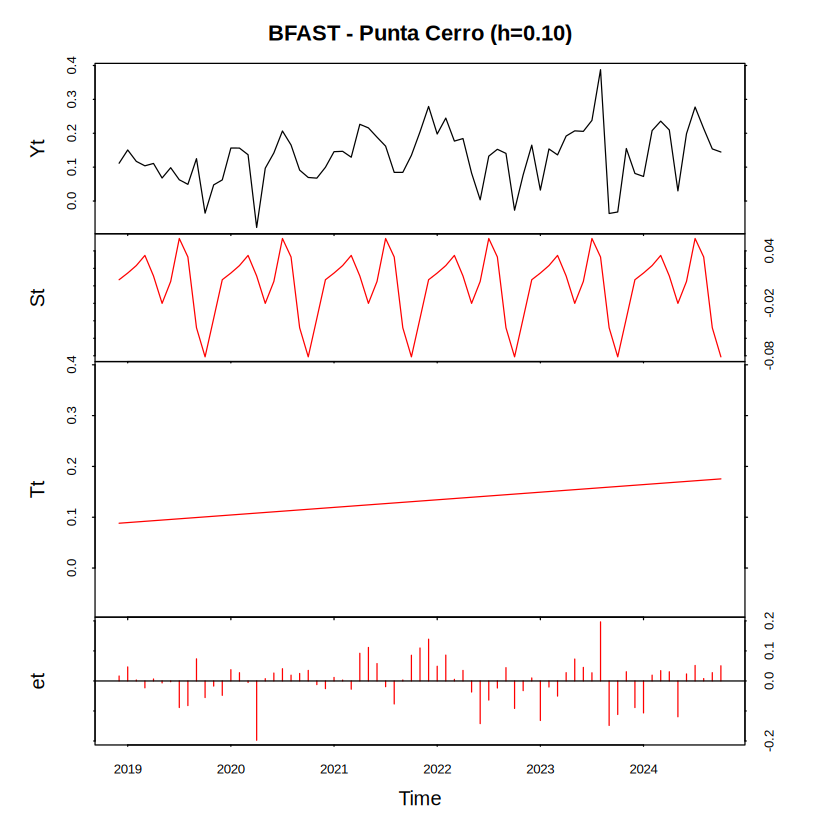

In [7]:
# Prueba con Punta_Cerro (la que tuvo NDVI negativo en 2020)
sub <- df %>% filter(subzona == "Punta_Cerro") %>% arrange(date) %>% filter(!is.na(ndvi))
ts_ndvi <- ts(sub$ndvi, start=c(2018,12), frequency=12)
bf2 <- bfast(ts_ndvi, h=0.10, season="harmonic", max.iter=10)
plot(bf2, main="BFAST - Punta Cerro (h=0.10)")
cat("Quiebres tendencia:", ifelse(bf2$nobp$Vt, 0, length(bf2$Vt.bp)), "\n")

In [9]:
library(tidyverse)
library(bfast)

In [10]:
df <- read.csv("/home/rstudio/work/proyecto-cgsm/outputs/tables/serie_temporal_ndvi_definitiva.csv")

sub <- df %>%
  filter(subzona == "Punta_Cerro") %>%
  arrange(date) %>%
  filter(!is.na(ndvi))

cat("Registros Punta_Cerro:", nrow(sub), "\n")
head(sub)

Registros Punta_Cerro: 71 


,subzona,date,ndvi
,<chr>,<chr>,<dbl>
1,Punta_Cerro,2018-12-01,0.11159651
2,Punta_Cerro,2019-01-01,0.15068082
3,Punta_Cerro,2019-02-01,0.11701288
4,Punta_Cerro,2019-03-01,0.10392052
5,Punta_Cerro,2019-04-01,0.11089745
6,Punta_Cerro,2019-06-01,0.06796292


In [11]:
ts_ndvi <- ts(sub$ndvi, start = c(2018, 12), frequency = 12)
bf <- bfast(ts_ndvi, h = 0.10, season = "harmonic", max.iter = 10)

cat("Quiebres tendencia:",
    ifelse(bf$nobp$Vt, 0, length(bf$Vt.bp)), "\n")

Quiebres tendencia: 0 


In [12]:
n <- length(ts_ndvi)
fechas <- seq(as.Date("2018-12-01"), by = "month", length.out = n)

residuos <- if (!is.null(bf$output[[1]]$Vt)) {
  as.numeric(bf$output[[1]]$Vt)
} else {
  as.numeric(bf$output[[1]]$et)
}

componentes <- tibble(
  fecha = rep(fechas, 4),
  componente = rep(c("Yt — Serie observada",
                      "St — Estacionalidad",
                      "Tt — Tendencia",
                      "et — Residuos"), each = n),
  valor = c(as.numeric(ts_ndvi),
            as.numeric(bf$output[[1]]$St),
            as.numeric(bf$output[[1]]$Tt),
            residuos)
)

componentes$componente <- factor(
  componentes$componente,
  levels = c("Yt — Serie observada",
             "St — Estacionalidad",
             "Tt — Tendencia",
             "et — Residuos")
)

cat("Componentes listos:", nrow(componentes), "filas\n")

Componentes listos: 284 filas


Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


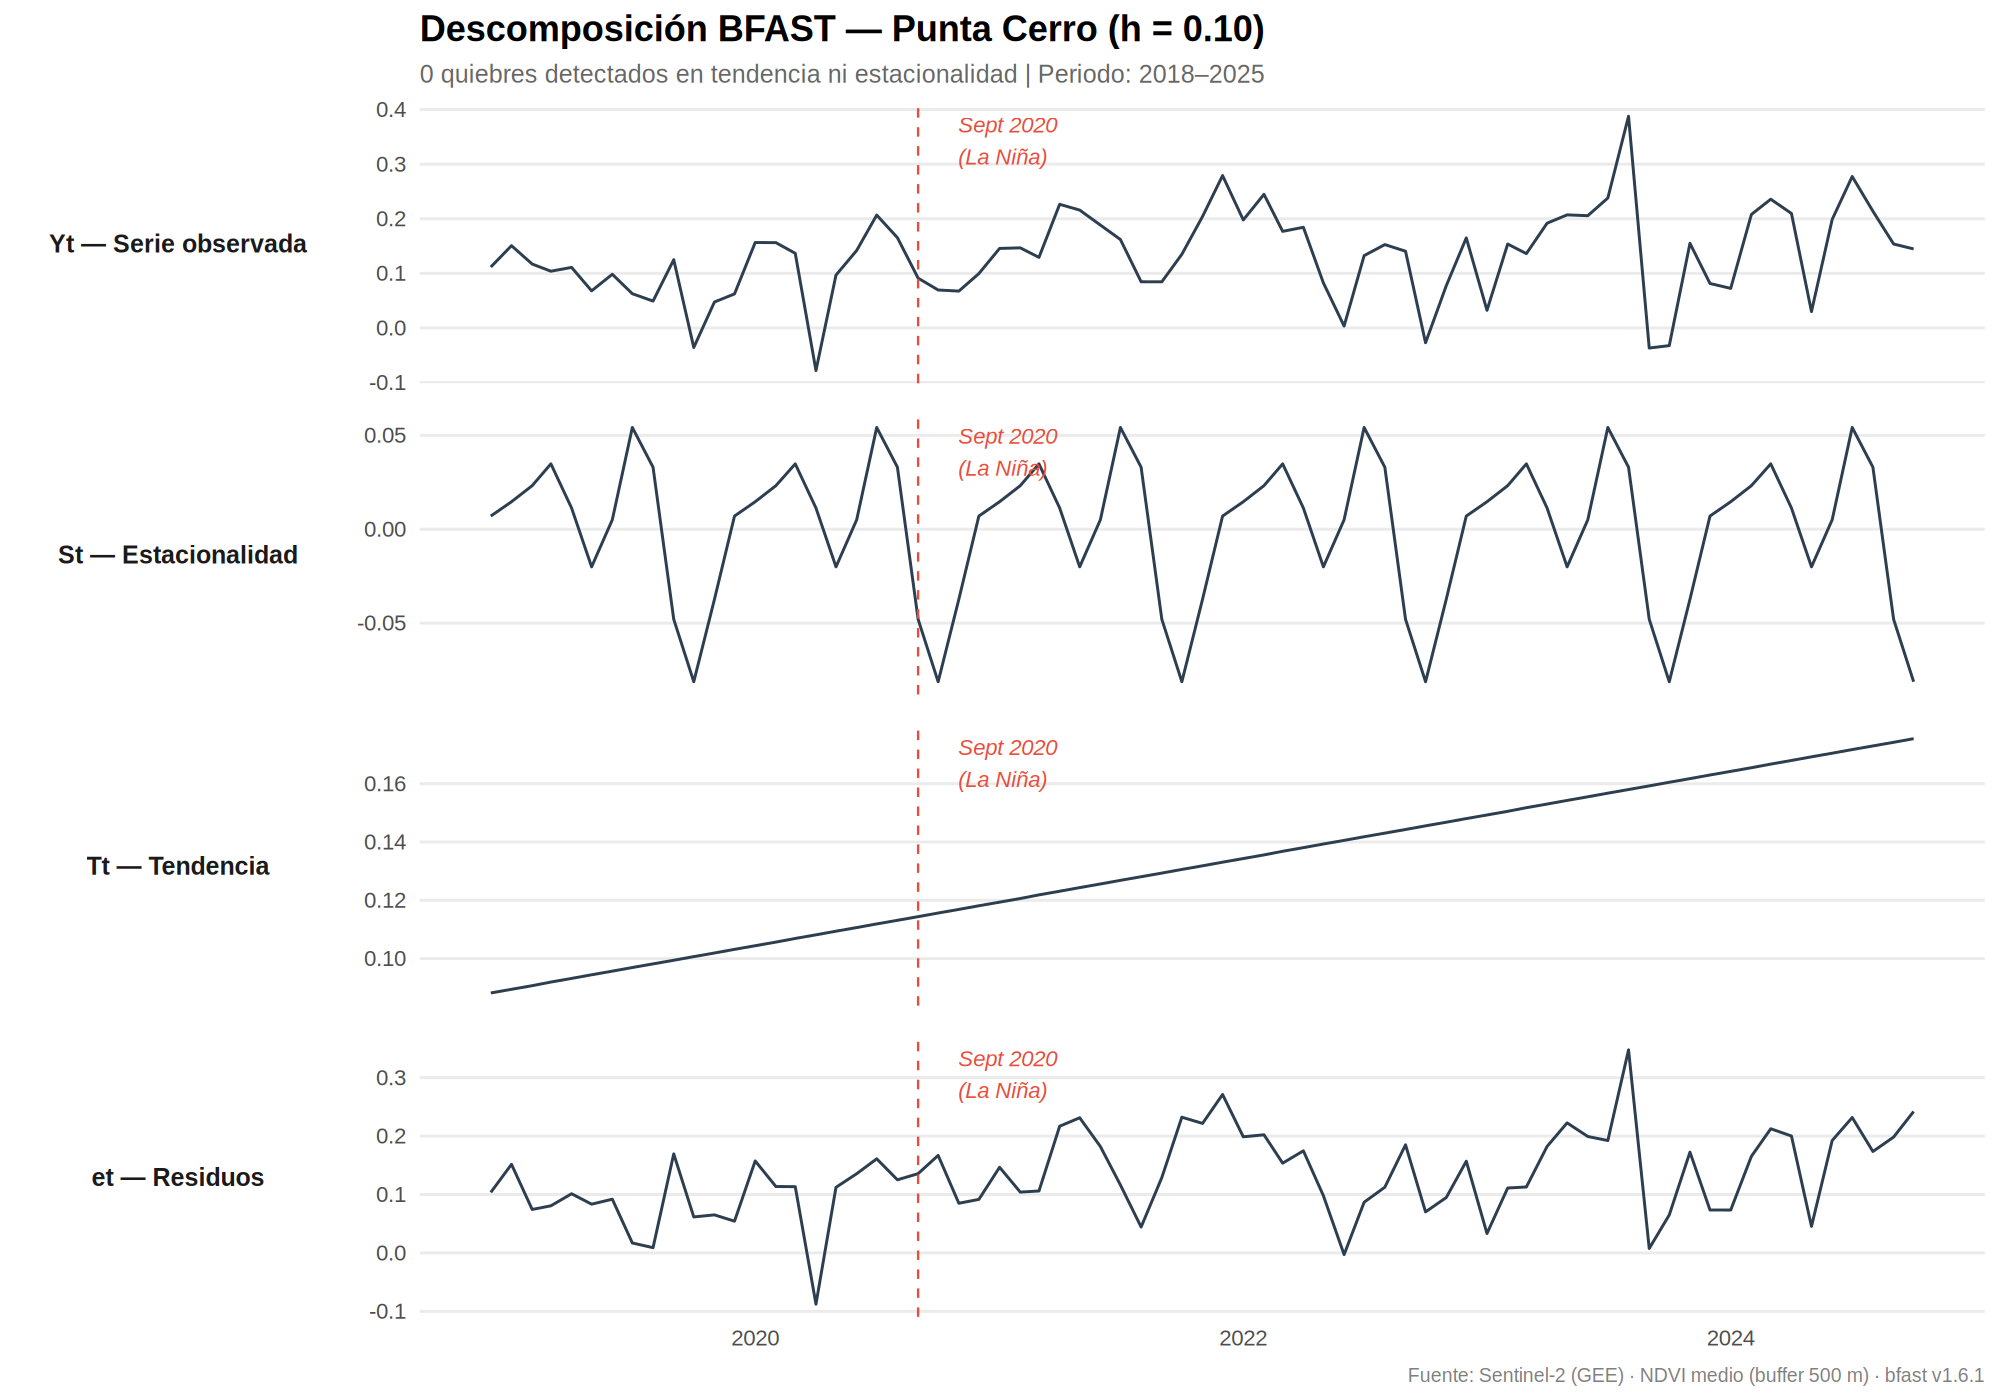

In [13]:
fecha_evento <- as.Date("2020-09-01")

options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

p <- ggplot(componentes, aes(x = fecha, y = valor)) +
  geom_line(color = "#2c3e50", linewidth = 0.5) +
  geom_vline(xintercept = as.numeric(fecha_evento),
             linetype = "dashed", color = "#e74c3c", linewidth = 0.4) +
  facet_wrap(~ componente, ncol = 1, scales = "free_y",
             strip.position = "left") +
  annotate("text", x = fecha_evento + 60, y = Inf,
           label = "Sept 2020\n(La Niña)",
           hjust = 0, vjust = 1.3, size = 2.8,
           color = "#e74c3c", fontface = "italic") +
  labs(
    title = "Descomposición BFAST — Punta Cerro (h = 0.10)",
    subtitle = "0 quiebres detectados en tendencia ni estacionalidad | Periodo: 2018–2025",
    x = NULL,
    y = NULL,
    caption = "Fuente: Sentinel-2 (GEE) · NDVI medio (buffer 500 m) · bfast v1.6.1"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title       = element_text(face = "bold", size = 13, hjust = 0),
    plot.subtitle    = element_text(size = 9, color = "grey40", hjust = 0),
    plot.caption     = element_text(size = 7, color = "grey50", hjust = 1),
    strip.text.y.left = element_text(angle = 0, face = "bold", size = 9),
    strip.placement  = "outside",
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.spacing    = unit(0.4, "cm"),
    axis.text        = element_text(size = 8)
  )

print(p)

In [14]:
ggsave("/home/rstudio/work/proyecto-cgsm/outputs/figures/bfast_punta_cerro_h010_ggplot.png",
       plot = p, width = 22, height = 16, units = "cm", dpi = 300)

cat("Guardado en outputs/figures/bfast_punta_cerro_h010_ggplot.png\n")

Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


Guardado en outputs/figures/bfast_punta_cerro_h010_ggplot.png


In [1]:
# === BFAST con serie combinada 2013–2025 (Landsat + Sentinel-2) ===
library(bfast)
library(ggplot2)

# Cargar serie combinada
df <- read.csv('../outputs/tables/ndvi_combinado_2013_2025.csv')
df$fecha_date <- as.Date(paste0(df$fecha, "-01"))

cat("Serie combinada cargada:", nrow(df), "registros\n")
cat("Rango:", as.character(min(df$fecha_date)), "a", as.character(max(df$fecha_date)), "\n")
cat("Estaciones:", paste(unique(df$estacion), collapse=", "), "\n\n")

# Función para aplicar bfast a una estación
run_bfast <- function(station_name, h_val=0.10) {
  sub <- df[df$estacion == station_name, ]
  sub <- sub[order(sub$fecha_date), ]
  
  # Crear serie temporal mensual
  ndvi_vals <- sub$ndvi
  start_year <- as.numeric(format(min(sub$fecha_date), "%Y"))
  start_month <- as.numeric(format(min(sub$fecha_date), "%m"))
  
  ts_ndvi <- ts(ndvi_vals, start=c(start_year, start_month), frequency=12)
  
  cat(sprintf("=== %s (n=%d, %d-%d) ===\n", station_name, length(ndvi_vals), 
              start_year, as.numeric(format(max(sub$fecha_date), "%Y"))))
  
  tryCatch({
    bf <- bfast(ts_ndvi, h=h_val, season="harmonic", max.iter=5)
    
    n_breaks <- length(bf$output[[1]]$bp.Vt$breakpoints)
    cat(sprintf("  h=%.2f → %d quiebre(s) detectado(s)\n", h_val, n_breaks))
    
    if (n_breaks > 0) {
      bp_times <- time(ts_ndvi)[bf$output[[1]]$bp.Vt$breakpoints]
      for (i in 1:n_breaks) {
        bp_year <- floor(bp_times[i])
        bp_month <- round((bp_times[i] - bp_year) * 12) + 1
        cat(sprintf("    Quiebre %d: %d-%02d\n", i, bp_year, bp_month))
      }
    }
    
    return(list(station=station_name, bf=bf, n_breaks=n_breaks, ts=ts_ndvi))
  }, error=function(e) {
    cat(sprintf("  Error: %s\n", e$message))
    return(list(station=station_name, bf=NULL, n_breaks=0, ts=ts_ndvi))
  })
}

# Ejecutar bfast para todas las estaciones
stations <- unique(df$estacion)
results <- list()

cat("=== BFAST h=0.10 (serie 2013–2025, 12 años) ===\n\n")
for (s in stations) {
  results[[s]] <- run_bfast(s, h_val=0.10)
  cat("\n")
}

# Resumen
cat("\n=== RESUMEN BFAST ===\n")
cat(sprintf("%-20s %10s %10s\n", "Estación", "Quiebres", "Período"))
cat(paste(rep("-", 42), collapse=""), "\n")
for (s in stations) {
  r <- results[[s]]
  cat(sprintf("%-20s %10d %10s\n", s, r$n_breaks, "2013-2025"))
}

# También probar h=0.15
cat("\n=== BFAST h=0.15 (serie 2013–2025) ===\n\n")
for (s in stations) {
  run_bfast(s, h_val=0.15)
  cat("\n")
}

Loading required package: strucchangeRcpp

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich



Serie combinada cargada: 929 registros
Rango: 2013-04-01 a 2025-12-01 
Estaciones: CP Pajarales, Caño Clarín, Caño Palos, Isla Boquerón, Punta Cerro, Punta Chino, Río Sevilla, VIPIS 

=== BFAST h=0.10 (serie 2013–2025, 12 años) ===

=== CP Pajarales (n=129, 2013-2025) ===
  h=0.10 → 1 quiebre(s) detectado(s)
    Quiebre 1: 2016-10

=== Caño Clarín (n=99, 2013-2025) ===
  h=0.10 → 1 quiebre(s) detectado(s)
    Quiebre 1: 2016-09

=== Caño Palos (n=110, 2013-2025) ===
  Error: $ operator is invalid for atomic vectors

=== Isla Boquerón (n=116, 2013-2025) ===
  h=0.10 → 2 quiebre(s) detectado(s)
    Quiebre 1: 2016-04
    Quiebre 2: 2018-05

=== Punta Cerro (n=115, 2013-2025) ===
  h=0.10 → 3 quiebre(s) detectado(s)
    Quiebre 1: 2016-11
    Quiebre 2: 2020-04
    Quiebre 3: 2021-08

=== Punta Chino (n=116, 2013-2025) ===
  h=0.10 → 2 quiebre(s) detectado(s)
    Quiebre 1: 2015-04
    Quiebre 2: 2016-04

=== Río Sevilla (n=117, 2013-2025) ===
  h=0.10 → 1 quiebre(s) detectado(s)
    Quie